In [1]:
import sys
# Add your lenscarf site-packages to the path
sys.path.append('/users/odarwish/lenscarf/lib/python3.12/site-packages')

import numpy as np

import matplotlib.pyplot as plt

sys.path.append('/users/odarwish/abacusutils/')

from abacusnbody.data.read_abacus import read_asdf

import numpy as np

from abacusnbody.analysis.tsc import tsc_parallel

import matplotlib.pyplot as plt

from abacusnbody.analysis.power_spectrum import calc_power, calc_pk_from_deltak, get_k_mu_edges
from abacusnbody.analysis import power_spectrum as ps

from scipy.fft import rfftn, irfftn

import astropy

from classy import Class

import yaml

from pathlib import Path


import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.ticker import LogLocator, LogFormatter, AutoMinorLocator
from matplotlib.gridspec import GridSpec
from matplotlib import patheffects
import matplotlib as mpl

# ---- CONFIGURATION ----
# Use golden ratio for figure dimensions
GOLDEN_RATIO = (5**0.5 - 1) / 2
FIG_WIDTH = 5  # inches
FIG_HEIGHT = FIG_WIDTH * GOLDEN_RATIO
DPI = 300

# Check for and configure LaTeX if available (optional but professional)
# Uncomment this if you have LaTeX installed
# plt.rcParams.update({
#     "text.usetex": True,
#     "font.family": "serif",
#     "font.serif": ["Computer Modern Roman"],
# })

# If not using LaTeX, use a clean serif font
# Try to use TeX fonts that are included with matplotlib
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "Times New Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm"  # Use Computer Modern math font
})

# Define a modern, colorblind-friendly palette with higher contrast
# Based on colorblindness-friendly scientific palettes like viridis
# and ones recommended by Nature and Science publications
COLORBLIND_PALETTE = [
    '#0072B2',  # Blue
    '#D55E00',  # Orange
    '#009E73',  # Green
    '#CC79A7',  # Pink
    '#56B4E9',  # Light blue
    '#E69F00',  # Yellow
    '#000000',  # Black
    '#F0E442'   # Light yellow
]

In [2]:
key_selected = "n"

# More descriptive and professionally formatted names
names = {
    "n": r"$\mathcal{D}$",          # Using calligraphic D for density
    "x": r"$\varepsilon$",           # Using proper epsilon symbol
    "s": r"$\mathcal{S}$",           # Calligraphic S
    "t": r"$\mathcal{T}$",           # Calligraphic T
    "g": r"$\mathcal{G}$",           # Calligraphic G
    "x2": r"$10\varepsilon$"         # 10 epsilon
}

estimators_all = ["s", "g", "t", "n", "x", "x2"]
estimators_base = ["s", "g", "t", "x"]

In [18]:
configuration = 'config_abacus.yaml'
configuration = '../configs/abacus/config_abacus_kmax_01.yaml'

with open(configuration, 'r') as f:
    config = yaml.safe_load(f)
gen_nl_power = np.loadtxt(config['power_spectrum']['main_directory']+"/"+config['name']+"/"+config['power_spectrum']['nonlinear'])
gen_power = np.loadtxt(config['power_spectrum']['main_directory']+"/"+config['name']+"/"+config['power_spectrum']['linear'])
pnlinf = lambda kmag: jnp.interp(kmag, gen_nl_power[:,0], gen_nl_power[:,1])
plinf = lambda kmag: jnp.interp(kmag, gen_power[:,0], gen_power[:,1])
kmin, kmax = config['k_range']['kmin'], config['k_range']['kmax']

In [19]:
output_config = config['output']
filename_prefix = output_config['filename_prefix']
filename_prefix = output_config['filename_prefix']
output_dir = Path(output_config['directory'])/config['name']

In [20]:
output_config = config['output']
filename_prefix = output_config['filename_prefix']
filename_prefix = output_config['filename_prefix']
output_dir = Path(output_config['directory'])/config['name']
out_normalization_AB = np.load(output_dir / f"{filename_prefix}_normalization_AB.npy", allow_pickle = True).item()
out_variance_AB = np.load(output_dir / f"{filename_prefix}_variance_AB.npy", allow_pickle = True).item()



kr_config = config['k_range']
kmin = kr_config['kmin']
kmax = kr_config['kmax']
k_samples = kr_config['k_samples']
k_min_analysis = kr_config['k_min_analysis']
k_max_analysis = kr_config['k_max_analysis']

Ks = np.linspace(k_min_analysis, k_max_analysis, k_samples)

In [23]:
direc = f"/users/odarwish/qeep/results/{config['name']}/"
Ns = 3

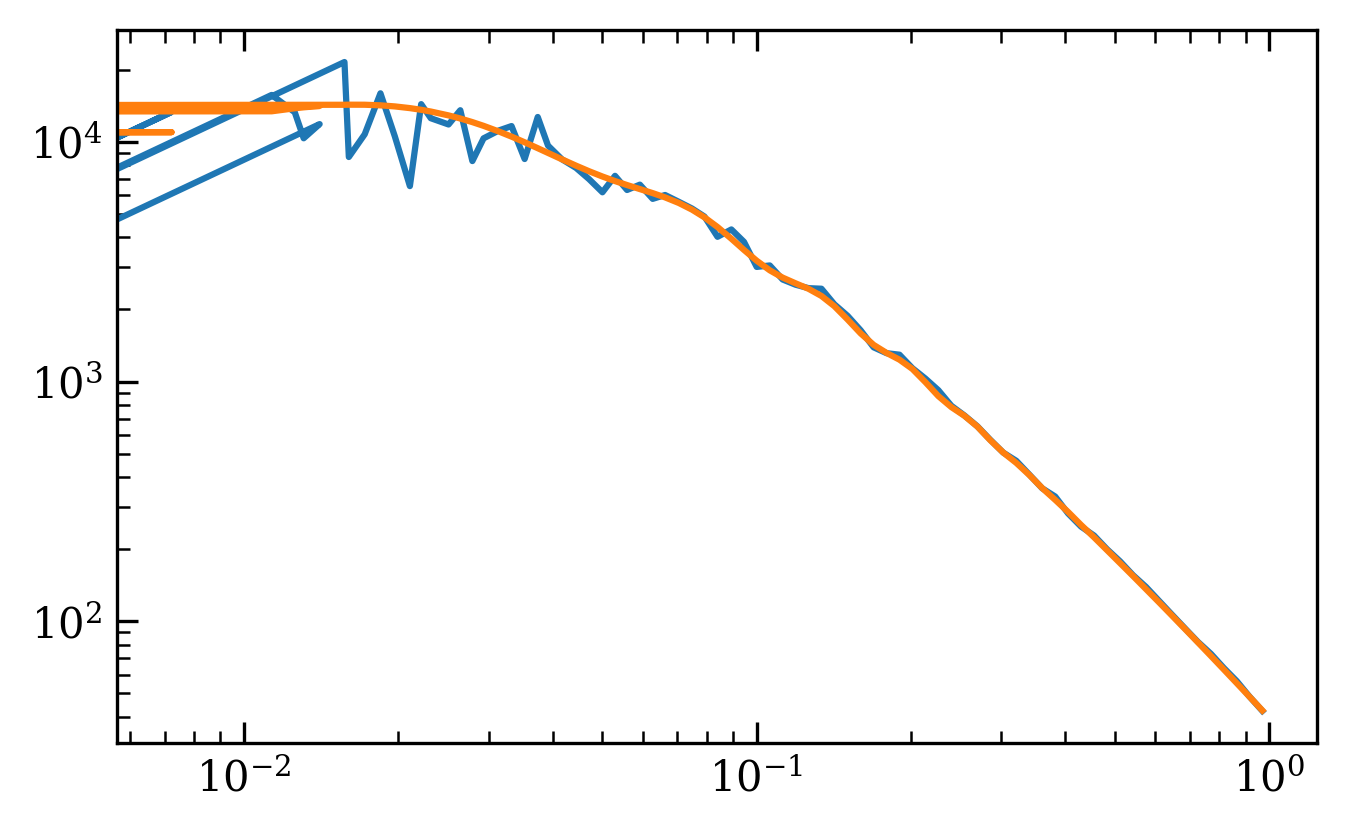

In [24]:
# ---- FIGURE CREATION ----
# Create figure with golden ratio and higher dpi
fig = plt.figure(figsize=(FIG_WIDTH, FIG_HEIGHT), dpi=DPI, facecolor='white')
# Use GridSpec for more control over plot layout
gs = GridSpec(1, 1, figure=fig, left=0.15, right=0.95, bottom=0.15, top=0.92)
ax = fig.add_subplot(gs[0, 0])

# Professional tick parameters
ax.tick_params(axis='both', which='major', direction='in', length=5, width=0.8, 
               top=True, right=False, labelsize=10)
ax.tick_params(axis='both', which='minor', direction='in', length=3, width=0.6, 
               top=True, right=False)

i = 0
color = COLORBLIND_PALETTE[i % len(COLORBLIND_PALETTE)]


# Set up clean, professional plot styling with pure white background
ax.set_facecolor('white')
for spine in ax.spines.values():
    spine.set_linewidth(0.8)
    spine.set_color('black')

pmean = 0
for i in range(Ns):
    results = np.load(direc+f"results_analysis_{i}.npy", allow_pickle = True).item()
    k, p = results['sim_linear_power']
    pmean += p
pmean /= Ns
plt.loglog(k, pmean)
plt.plot(k, np.interp(k, gen_power[:,0], gen_power[:,1]))

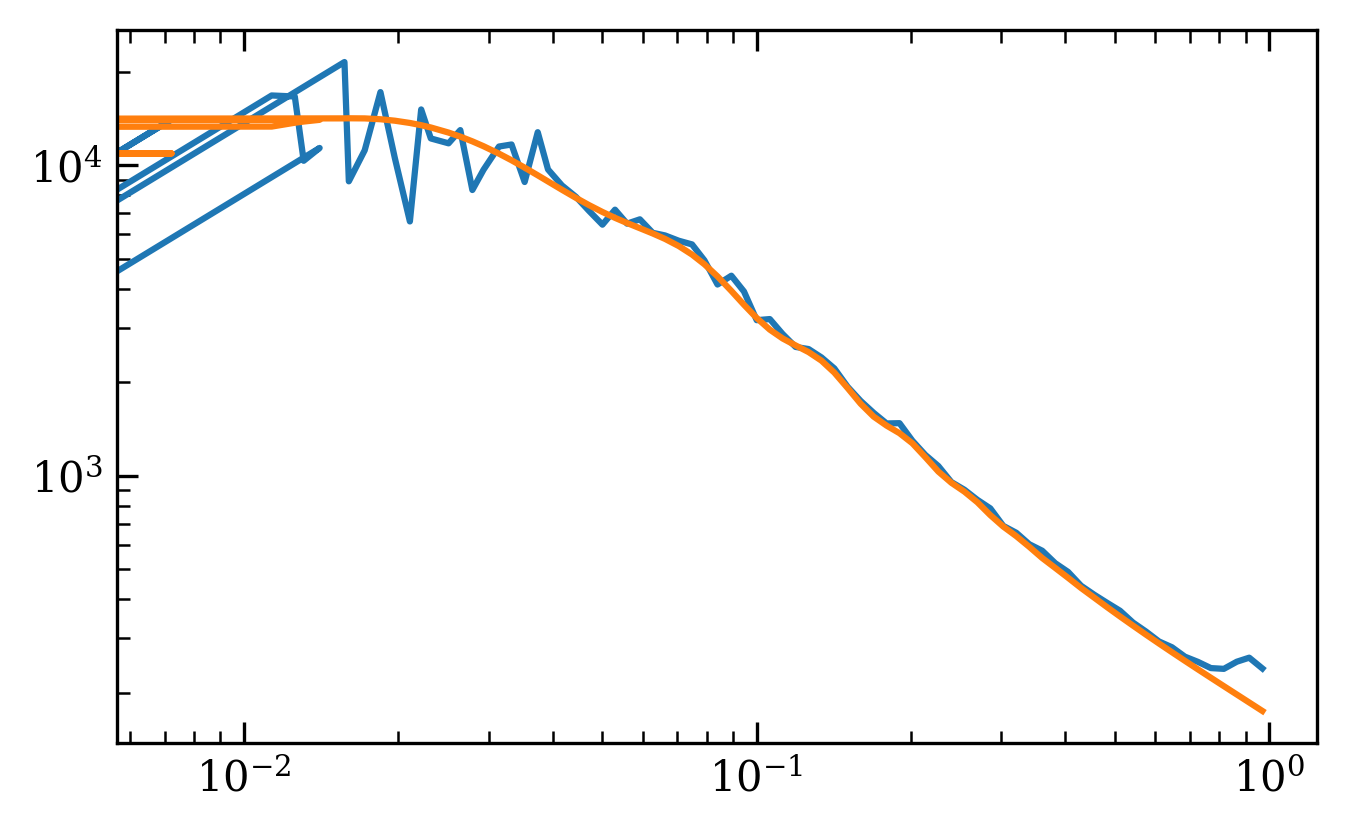

In [26]:
# ---- FIGURE CREATION ----
# Create figure with golden ratio and higher dpi
fig = plt.figure(figsize=(FIG_WIDTH, FIG_HEIGHT), dpi=DPI, facecolor='white')
# Use GridSpec for more control over plot layout
gs = GridSpec(1, 1, figure=fig, left=0.15, right=0.95, bottom=0.15, top=0.92)
ax = fig.add_subplot(gs[0, 0])

# Professional tick parameters
ax.tick_params(axis='both', which='major', direction='in', length=5, width=0.8, 
               top=True, right=False, labelsize=10)
ax.tick_params(axis='both', which='minor', direction='in', length=3, width=0.6, 
               top=True, right=False)

color = COLORBLIND_PALETTE[i % len(COLORBLIND_PALETTE)]

pmean = 0
for i in range(Ns):
    results = np.load(direc+f"results_analysis_{i}.npy", allow_pickle = True).item()
    k, p = results['sim_nonlinear_power']
    pmean += p
pmean /= Ns
ax.loglog(k, pmean)
ax.plot(k, np.interp(k, gen_nl_power[:,0], gen_nl_power[:,1]))
fig.savefig(f"../plots/nonlinear_power_spectrum.pdf", dpi = 300)
plt.show()
plt.close()

In [74]:
def plot(key, power, cross = False):

    # ---- FIGURE CREATION ----
    # Create figure with golden ratio and higher dpi
    fig = plt.figure(figsize=(FIG_WIDTH, FIG_HEIGHT), dpi=DPI, facecolor='white')
    # Use GridSpec for more control over plot layout
    gs = GridSpec(1, 1, figure=fig, left=0.15, right=0.95, bottom=0.15, top=0.92)
    ax = fig.add_subplot(gs[0, 0])
    caso = "auto" if not cross else "cross"
    ax.set_title(f"{names[key]} {caso}")
    
    # Professional tick parameters
    ax.tick_params(axis='both', which='major', direction='in', length=5, width=0.8, 
                   top=True, right=False, labelsize=10)
    ax.tick_params(axis='both', which='minor', direction='in', length=3, width=0.6, 
                   top=True, right=False)


    
    non_linear_pk_interp = np.interp(Ks, gen_nl_power[:,0], gen_nl_power[:,1])
    
    N = out_normalization_AB[(key, key)]**-1.
    v = out_variance_AB[(key, key)]
    variance = N**2*v

    
    if not cross:
        i = 0
        color = COLORBLIND_PALETTE[i % len(COLORBLIND_PALETTE)]
        ax.plot(Ks, N, label = "Normalization Noise", color = color)
        i = 1
        color = COLORBLIND_PALETTE[i % len(COLORBLIND_PALETTE)]
        ax.plot(Ks, N**2*v, label = "Variance", ls = "--", color = color)

    size = 191102976
    factor = 1/size**2
    
    bias = 0
    kinds = ["s", "t", "g"]
    for kk in kinds:
        bias += (N*out_normalization_AB[(key, kk)])
    
    linear_pk_interp = np.interp(Ks, gen_power[:,0], gen_power[:,1])
    i = 3
    color = COLORBLIND_PALETTE[i % len(COLORBLIND_PALETTE)]
    if cross:
        ax.loglog(Ks, abs(bias)*linear_pk_interp, ls = "--", color = color, label = "Prediction")
        V = 1000**3
        Nmodes = V*(Ks**2*(Ks[1]-Ks[0]))
        err2 = (bias**2*linear_pk_interp+variance)*linear_pk_interp+(abs(bias)*linear_pk_interp)**2
        err_bar_cross = np.sqrt(err2/Nmodes)
    else:
        ax.loglog(Ks, bias**2*linear_pk_interp+v*N**2, ls = "--", color = color, label = "Prediction")
    
    a, b = k_values, power*factor**(1+int(cross==False))
    b[0] = 0.
    b = b.astype(float)
    value = np.interp(Ks, a, b)*N**(1+int(cross==False))
    #if cross:
    #    ax.errorbar(Ks, value, err_bar_cross, label = "Reconstruction", color = "black", alpha = 0.4, ls = "", marker = "o")
    #else:
    ax.scatter(Ks, (value), label = "Reconstruction", color = "black", alpha = 0.4)
    
    #plt.ylim(1e-6, 1)
    #ax.set_xlim(2e-3, 1e-1)
    ax.set_xlim(2e-3, 5e-2)
    #ax.set_yscale("symlog", linthresh = 1e-1)

    #ax.set_xlabel(r'$K \ \mathrm{[h/Mpc]}$', fontsize=16)
    #ax.set_ylabel(r'$P(K) \mathrm{[h^3/Mpc^{3}]}$', fontsize=16)
    #ax.set_yscale("linear")
    ax.legend()

    fig.savefig(f"../plots/{key}_{caso}.pdf", dpi = 300)
    plt.show()
    plt.close()

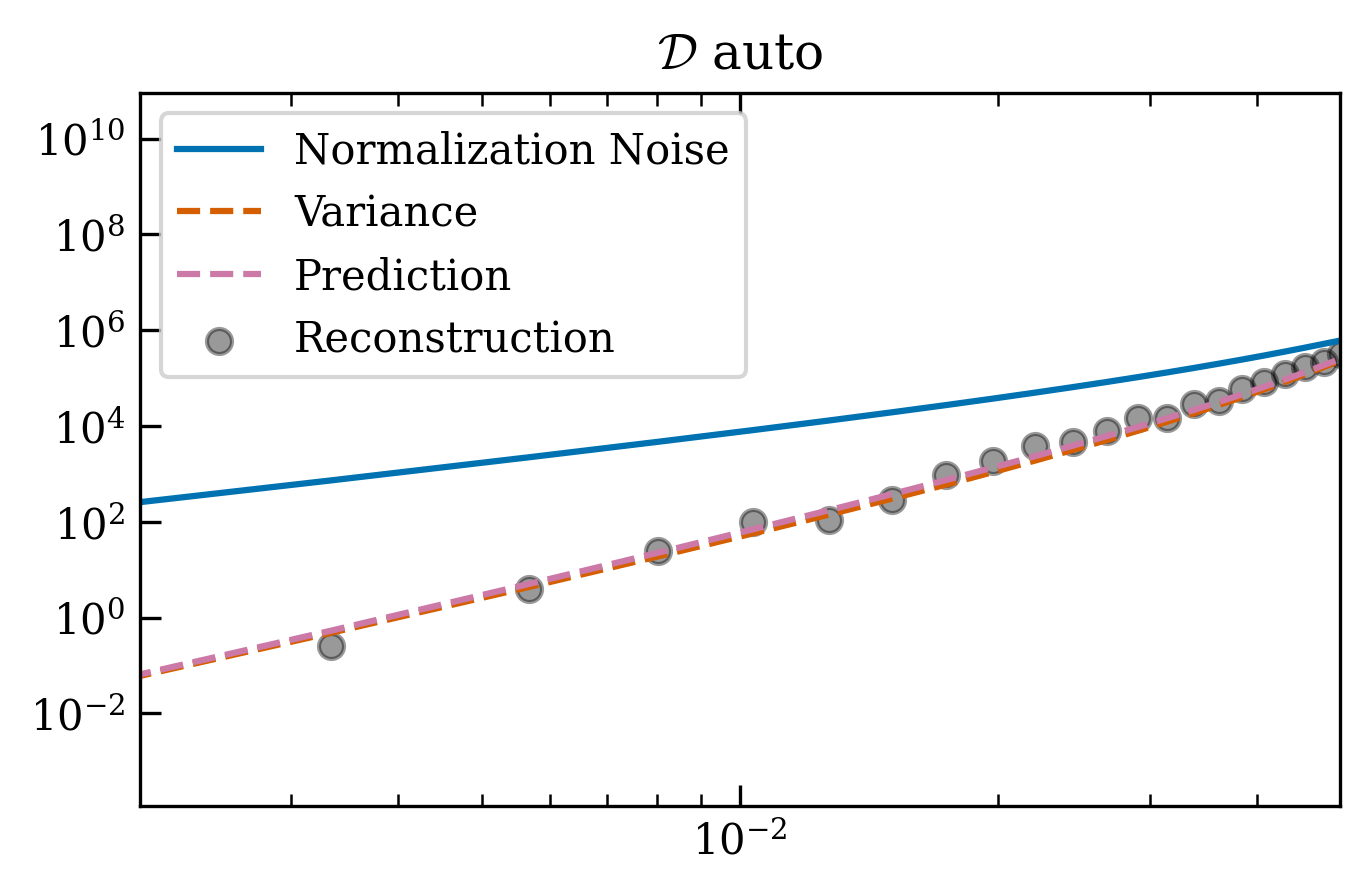

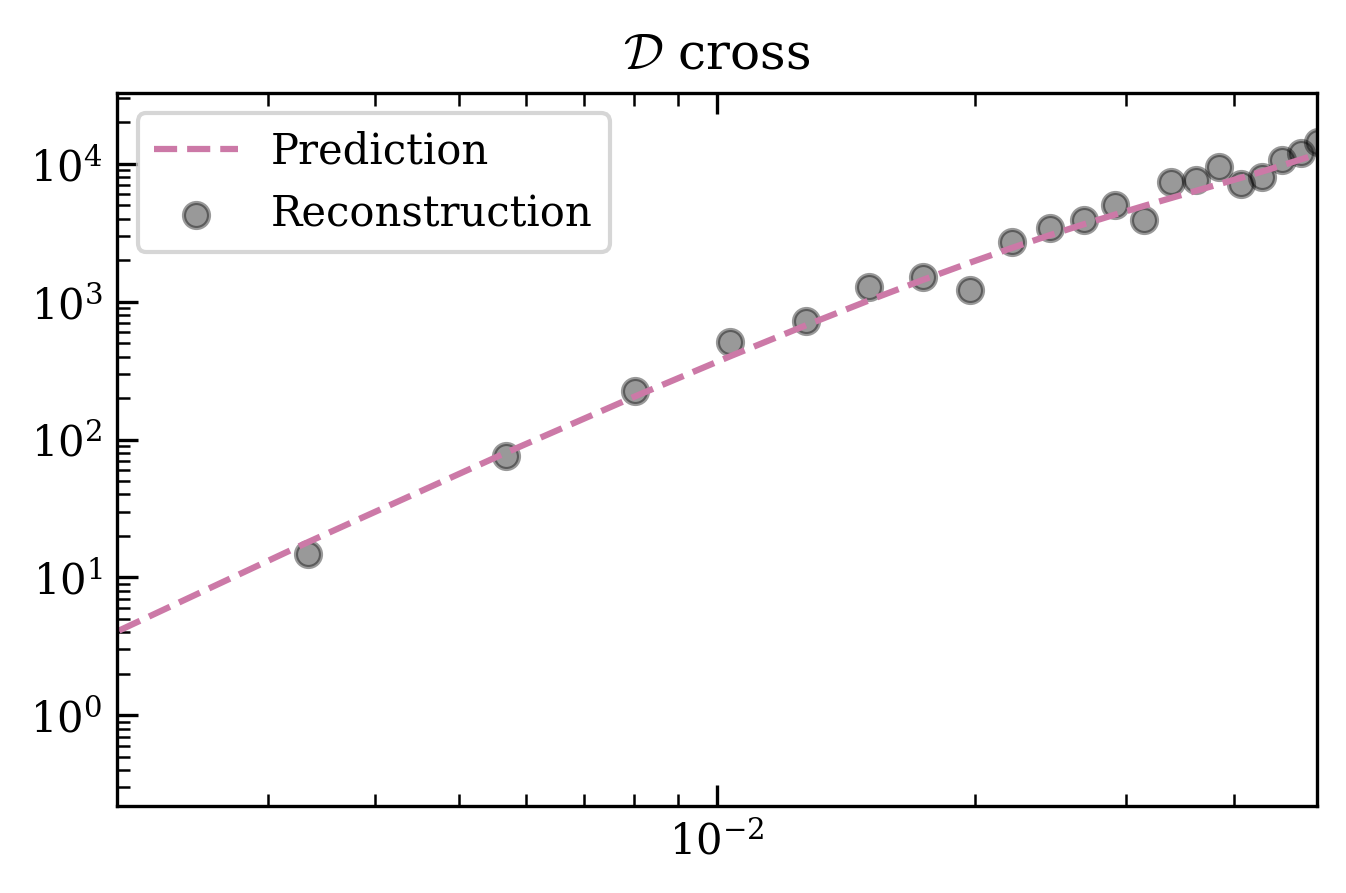

In [73]:
#for key in ["g", "s", "t", "n"]:
for key in ["n"]:
    power = 0
    power_cross = 0
    power_from_linear = 0
    for i in range(Ns):
        results = np.load(direc+f"results_analysis_{i}.npy", allow_pickle = True).item()
        k, p = results[key]['auto']
        power += p
    
        k, p = results[key]['cross']
        power_cross += p
    
        k, p = results[key]['auto_from_linear']
        power_from_linear += p
        
    power /= Ns
    power_cross /= Ns
    power_from_linear /= Ns
    
    k_values = k

    plot(key, power)
    plot(key, power_cross, True)